In [1]:
%load_ext autoreload
%autoreload 2

# Import Required Libraries
Import necessary libraries such as `torch`, `numpy`, and `matplotlib` for visualization.

In [2]:
# Import Required Libraries
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from Renderer import Renderer

# Define Helper Functions
Define helper functions to visualize the generated point clouds, such as plotting 3D scatter plots using `matplotlib`.

In [62]:
def plot_point_cloud(points, colors=None, title="Point Cloud"):
    """
    Visualize a 3D point cloud using matplotlib with fixed axes limits (0–100 for X, Y, Z).
    
    Args:
        points (numpy.ndarray): Array of shape (N, 3) representing 3D points.
        colors (numpy.ndarray): Optional array of shape (N, 3) for RGB colors.
        title (str): Title of the plot.
    """
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    
    # Ensure colors are properly formatted
    if colors is not None:
        if colors.shape[0] != points.shape[0]:
            colors = colors[:points.shape[0]]  # Adjust size if necessary
        ax.scatter(points[:, 0], points[:, 1], points[:, 2], c=colors, s=10)
    else:
        ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=10)
    
    # Set title and labels
    ax.set_title(title)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    
    # Set fixed axes limits
    ax.set_xlim(-100, 100)
    ax.set_ylim(-100, 100)
    ax.set_zlim(-100, 100)
    
    plt.show()

# Test `_initialize_random` with Default Parameters
Call the `_initialize_random` function with default parameters and visualize the resulting point cloud.

Number of points at initialization :  5000
Points shape: (5000, 3)
Colors shape: (5000, 1, 3)


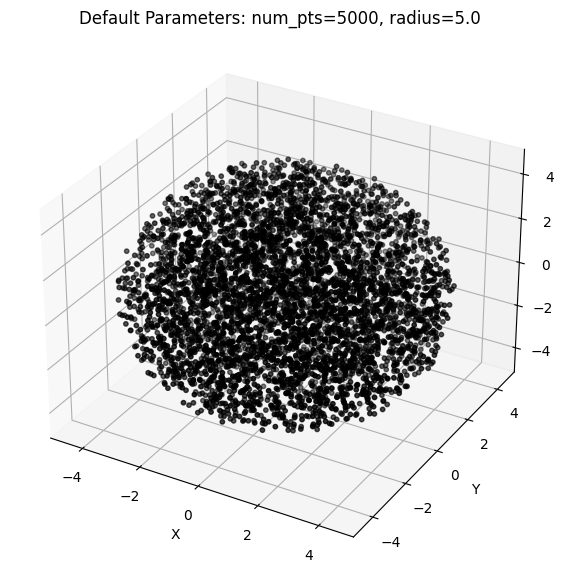

In [53]:
# Test `_initialize_random` with Default Parameters
renderer = Renderer(sh_degree=0)
num_pts = 5000
radius = 5.0

renderer._initialize_random(num_pts=num_pts, radius=radius)
points = renderer.gaussians_handler._mean.cpu().detach().numpy()
colors = renderer.gaussians_handler.get_features.cpu().detach().numpy()

print(f"Points shape: {points.shape}")
print(f"Colors shape: {colors.shape}")
plot_point_cloud(points, colors, title=f"Default Parameters: num_pts={num_pts}, radius={radius}")

# Vary Number of Points
Test `_initialize_random` with different values for `num_pts` (e.g., 100, 1000, 5000) and visualize how the density of the point cloud changes.

Number of points at initialization :  100


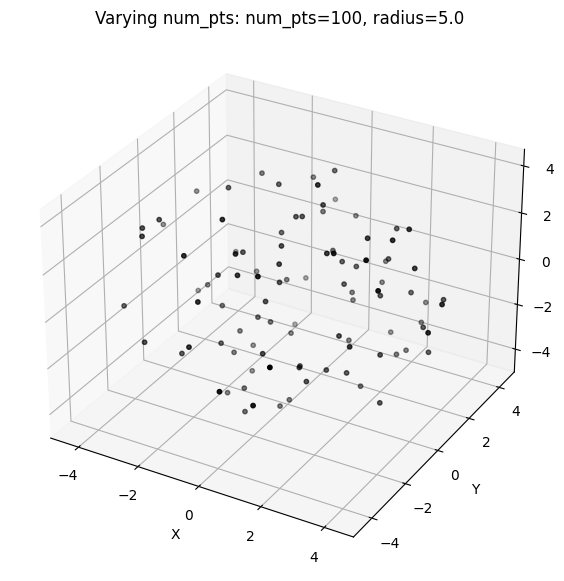

Number of points at initialization :  1000


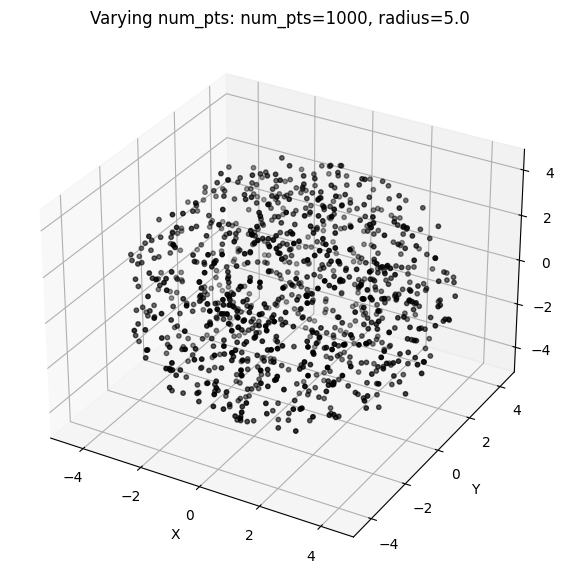

Number of points at initialization :  5000


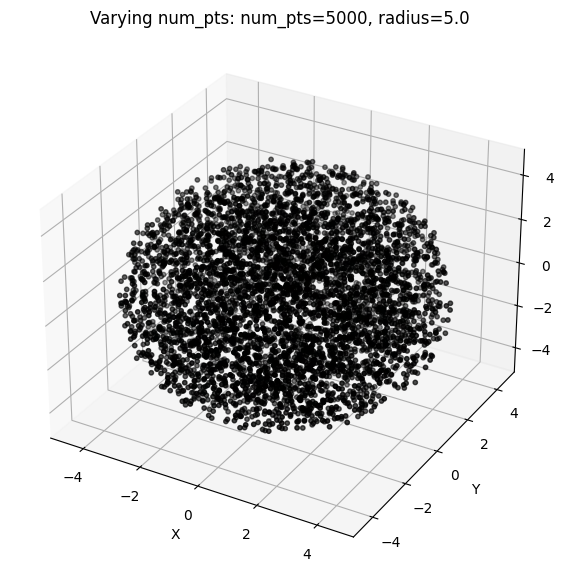

In [54]:
# Vary Number of Points
for num_pts in [100, 1000, 5000]:
    renderer._initialize_random(num_pts=num_pts, radius=radius)
    points = renderer.gaussians_handler._mean.cpu().detach().numpy()
    colors = renderer.gaussians_handler.get_features.cpu().detach().numpy()
    
    plot_point_cloud(points, colors, title=f"Varying num_pts: num_pts={num_pts}, radius={radius}")

# Vary Radius
Test `_initialize_random` with different values for `radius` (e.g., 0.5, 1.0, 2.0) and visualize how the spread of the point cloud changes.

Number of points at initialization :  1000
Points shape: (1000, 3)
max x: 9.728117942810059, min x: -9.775785446166992
max y: 9.807873725891113, min y: -9.297904968261719
max z: 9.427326202392578, min z: -9.632564544677734


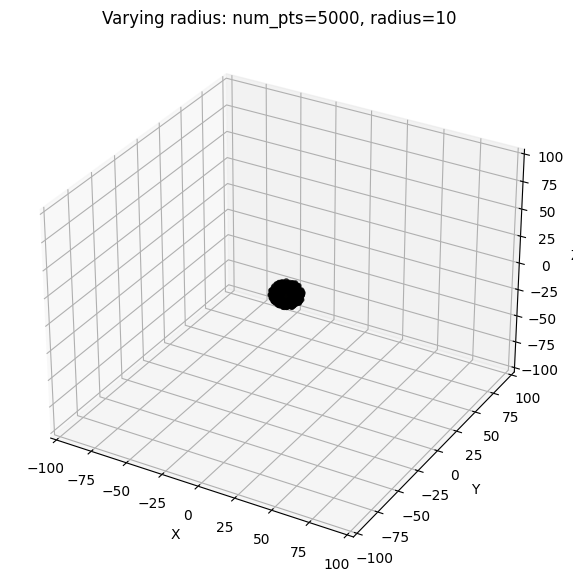

Number of points at initialization :  1000
Points shape: (1000, 3)
max x: 49.26690673828125, min x: -48.012969970703125
max y: 48.646827697753906, min y: -48.9369010925293
max z: 47.76931381225586, min z: -49.241477966308594


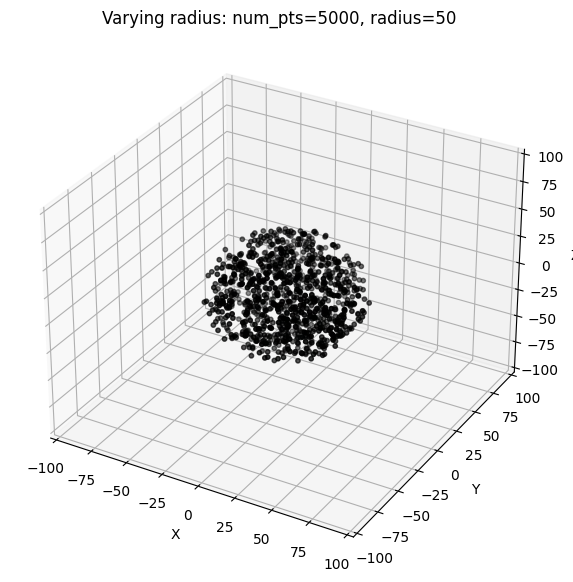

Number of points at initialization :  1000
Points shape: (1000, 3)
max x: 87.06208801269531, min x: -83.7232666015625
max y: 87.8851089477539, min y: -86.01207733154297
max z: 87.17826080322266, min z: -88.33782958984375


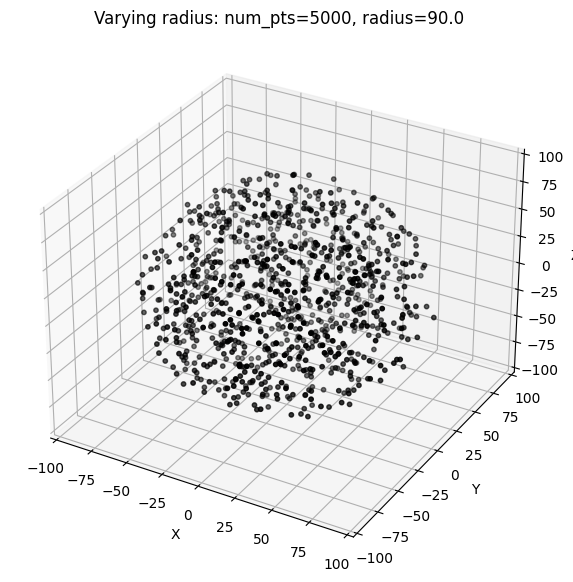

In [68]:
# Vary Radius
for r in [10, 50, 90.0]:
    renderer._initialize_random(num_pts=1000, radius=r)
    points = renderer.gaussians_handler._mean.cpu().detach().numpy()
    print(f"Points shape: {points.shape}")
    print(f"max x: {points[:, 0].max()}, min x: {points[:, 0].min()}")
    print(f"max y: {points[:, 1].max()}, min y: {points[:, 1].min()}")
    print(f"max z: {points[:, 2].max()}, min z: {points[:, 2].min()}")
    colors = renderer.gaussians_handler.get_features.cpu().detach().numpy()
    
    plot_point_cloud(points, colors, title=f"Varying radius: num_pts={num_pts}, radius={r}")

# Vary Axes Scales
Test `_initialize_random` with different values for `scales` and visualize how the spread of the point cloud changes.

Number of points at initialization :  5000


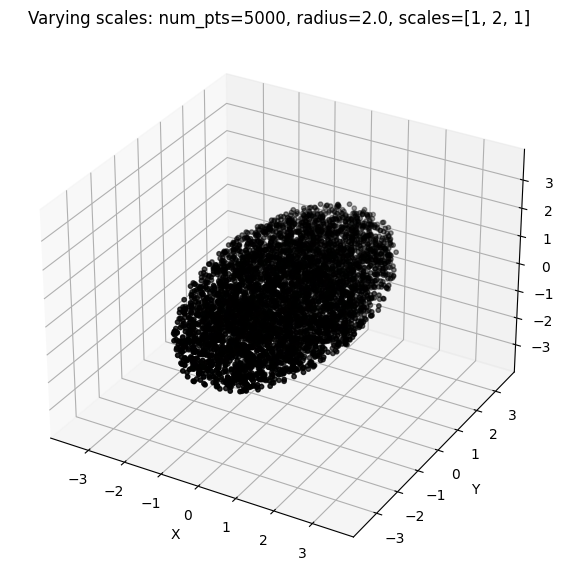

Number of points at initialization :  5000


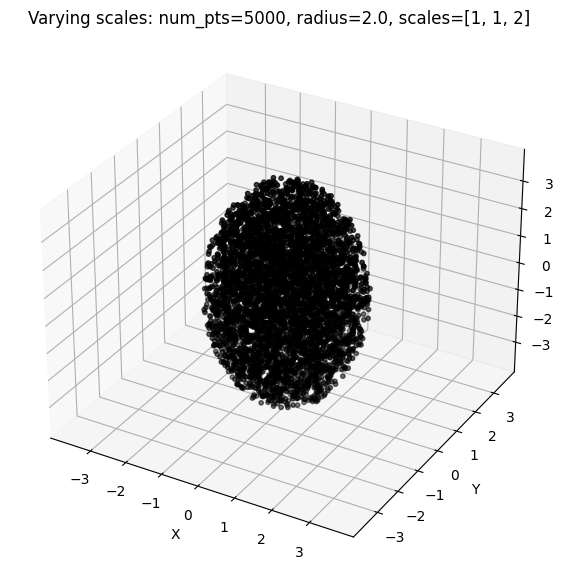

Number of points at initialization :  5000


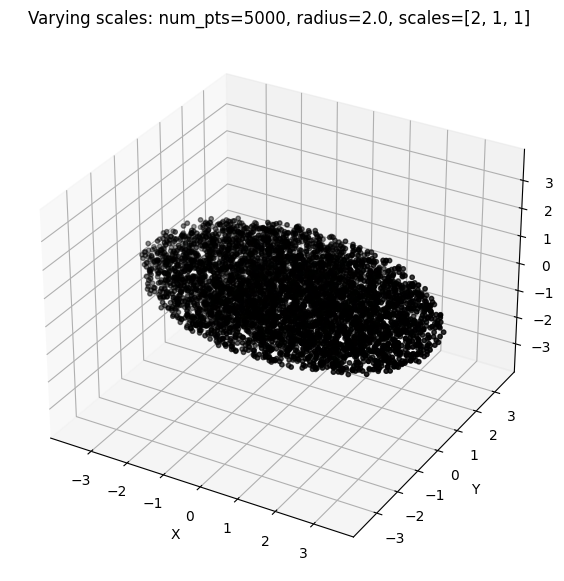

In [22]:
for scales in [[1,2,1], [1,1,2], [2,1,1]]:
    renderer._initialize_random(num_pts=num_pts, radius=radius, scales=scales)
    points = renderer.gaussians_handler._mean.cpu().detach().numpy()
    colors = renderer.gaussians_handler.get_features.cpu().detach().numpy()
    
    plot_point_cloud(points, colors, title=f"Varying scales: num_pts={num_pts}, radius={radius}, scales={scales}")

# Visualize Results
Combine the visualizations into a grid or sequence to compare the effects of varying parameters side by side.

In [ ]:
# Visualize Results
fig, axes = plt.subplots(2, 3, figsize=(18, 12), subplot_kw={'projection': '3d'})

# Varying num_pts
for i, num_pts in enumerate([100, 1000, 5000]):
    renderer._initialize_random(num_pts=num_pts, radius=1.0)
    points = renderer.gaussians_handler._mean.cpu().numpy()
    colors = renderer.gaussians_handler.get_features.cpu().numpy()
    
    ax = axes[0, i]
    ax.scatter(points[:, 0], points[:, 1], points[:, 2], c=colors, s=1)
    ax.set_title(f"num_pts={num_pts}, radius=1.0")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")

# Varying radius
for i, radius in enumerate([0.5, 1.0, 2.0]):
    renderer._initialize_random(num_pts=1000, radius=radius)
    points = renderer.gaussians_handler._mean.cpu().numpy()
    colors = renderer.gaussians_handler.get_features.cpu().numpy()
    
    ax = axes[1, i]
    ax.scatter(points[:, 0], points[:, 1], points[:, 2], c=colors, s=1)
    ax.set_title(f"num_pts=1000, radius={radius}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")

plt.tight_layout()
plt.show()